This notebook was run on a Colab kernel.

# Setup

---
---

**Mount Drive**

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Verify Folder structure in drive**

In [23]:
import os
from collections import Counter

def verify_dataset(base_paths):
    print("VERIFYING DATASET STRUCTURE...")
    print("=" * 60)

    total_dataset_size = 0
    total_dataset_files = 0

    for base_path in base_paths:
        if not os.path.exists(base_path):
            print(f"Not found: {base_path} (Skipping)")
            continue

        for root, dirs, files in os.walk(base_path):
            folder_size = sum(os.path.getsize(os.path.join(root, f)) for f in files)
            total_dataset_size += folder_size
            total_dataset_files += len(files)

            ext_counts = Counter(os.path.splitext(f)[1].lower() for f in files)

            level = root.replace(base_path, '').count(os.sep)
            indent = ' ' * 4 * level
            folder_name = os.path.basename(root) if root != base_path else os.path.basename(base_path)

            print(f"{indent} {folder_name}/  [{len(files)} files | {folder_size / (1024*1024):.2f} MB]")

            if files:
                for ext, count in ext_counts.items():
                    ext_name = ext if ext else "no_extension"
                    print(f"{indent}    ├── {count} {ext_name} files")

                examples = sorted(files)
                if len(files) >= 3:
                    examples_str = f"{examples[0]}, {examples[1]}, {examples[2]}, ..."
                else:
                    examples_str = ", ".join(examples)
                print(f"{indent}    └── Examples: {examples_str}\n")
            else:
                print(f"{indent}    └── (Empty folder)\n")

    print("=" * 60)
    print(f"Total Dataset Files: {total_dataset_files}")
    print(f"Total Dataset Size:  {total_dataset_size / (1024*1024):.2f} MB")

paths_to_check = [
    '/content/drive/MyDrive/pheno_crop',
]

verify_dataset(paths_to_check)

# we don't need the sentinel_2_mixed_temp folder .. ignore it for now

VERIFYING DATASET STRUCTURE...
 pheno_crop/  [9 files | 2.55 MB]
    ├── 5 .csv files
    ├── 4 .pth files
    └── Examples: best_model_bilstm.pth, best_model_gru.pth, best_model_lstm.pth, ...

     sentinel_2/  [52 files | 0.95 MB]
        ├── 52 .csv files
        └── Examples: plot_10_indices.csv, plot_11_indices.csv, plot_12_indices.csv, ...

     sentinel_1/  [52 files | 0.17 MB]
        ├── 52 .csv files
        └── Examples: plot_10_sar.csv, plot_11_sar.csv, plot_12_sar.csv, ...

     sentinel_2_mixed_temp/  [239 files | 0.92 MB]
        ├── 227 .tif files
        ├── 12 .csv files
        └── Examples: plot_10_indices.csv, plot_11_indices.csv, plot_12_indices.csv, ...

Total Dataset Files: 352
Total Dataset Size:  4.59 MB


###Setting up the dataset

In [24]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

class ProductionPhenologyDataset(Dataset):
    def __init__(self, gt_path, s1_dir, s2_dir, plot_ids, lookback_days=90, max_seq_len=30):
        self.lookback_days = lookback_days
        self.max_seq_len = max_seq_len

        self.gt = pd.read_csv(gt_path)
        self.gt['date'] = pd.to_datetime(self.gt['date'])
        self.gt = self.gt[self.gt['plot_id'].isin(plot_ids)].reset_index(drop=True)

        self.s1_data, self.s2_data = {}, {}

        print("Loading CSVs into memory...")
        for pid in plot_ids:
            s1_path = os.path.join(s1_dir, f"plot_{pid}_sar.csv")
            if os.path.exists(s1_path):
                df1 = pd.read_csv(s1_path)
                df1['date'] = pd.to_datetime(df1['date'])
                self.s1_data[pid] = df1

            s2_path = os.path.join(s2_dir, f"plot_{pid}_indices.csv")
            if os.path.exists(s2_path):
                df2 = pd.read_csv(s2_path)
                df2['date'] = pd.to_datetime(df2['date'])
                self.s2_data[pid] = df2
        print(f"Dataset ready. Found {len(self.gt)} ground truth events.")

    def __len__(self): return len(self.gt)

    def __getitem__(self, idx):
        row = self.gt.iloc[idx]
        target_date, plot_id, label = row['date'], row['plot_id'], row['stage_code']
        start_date = target_date - pd.Timedelta(days=self.lookback_days)

        s1_df = self.s1_data.get(plot_id, pd.DataFrame())
        s1_tensor = torch.zeros((self.max_seq_len, 3), dtype=torch.float32)
        s1_days_tensor = torch.zeros((self.max_seq_len,), dtype=torch.float32)

        if not s1_df.empty:
            mask = (s1_df['date'] > start_date) & (s1_df['date'] <= target_date)
            valid_s1 = s1_df[mask]
            if len(valid_s1) > 0:
                features = valid_s1[['VV', 'VH', 'VH_VV_Ratio']].values
                days_ago = (target_date - valid_s1['date']).dt.days.values
                seq_len = min(len(features), self.max_seq_len)
                s1_tensor[-seq_len:] = torch.tensor(features[-seq_len:], dtype=torch.float32)
                s1_days_tensor[-seq_len:] = torch.tensor(days_ago[-seq_len:], dtype=torch.float32)

        s2_df = self.s2_data.get(plot_id, pd.DataFrame())
        s2_tensor = torch.zeros((self.max_seq_len, 9), dtype=torch.float32)
        s2_days_tensor = torch.zeros((self.max_seq_len,), dtype=torch.float32)

        if not s2_df.empty:
            mask = (s2_df['date'] > start_date) & (s2_df['date'] <= target_date)
            valid_s2 = s2_df[mask]
            if len(valid_s2) > 0:
                features = valid_s2[['NDVI', 'NDWI', 'NDRE', 'EVI', 'SAVI', 'MSAVI', 'NDMI', 'GNDVI', 'cloud_pct']].values
                days_ago = (target_date - valid_s2['date']).dt.days.values
                seq_len = min(len(features), self.max_seq_len)
                s2_tensor[-seq_len:] = torch.tensor(features[-seq_len:], dtype=torch.float32)
                s2_days_tensor[-seq_len:] = torch.tensor(days_ago[-seq_len:], dtype=torch.float32)

        return {
            's1_feats': s1_tensor, 's1_days': s1_days_tensor,
            's2_feats': s2_tensor, 's2_days': s2_days_tensor,
            'label': torch.tensor(label, dtype=torch.long)
        }

---
---

#  Baseline Temporal Sequence Models (LSTM / GRU / BiLSTM)

###Architecture Blueprint

These models serve as baseline sequence learners to benchmark the performance of the advanced dual-stream fusion network. Unlike the hybrid model, they treat the multimodal satellite data as a single fused time-series, without explicitly modeling modality-specific dynamics.

The goal is to evaluate how well standard recurrent architectures can learn crop growth patterns without specialized fusion mechanisms.


#Phase 1: Unified Time-Series Construction

Purpose:
To convert heterogeneous Sentinel-1 (Radar) and Sentinel-2 (Optical) signals into a single sequential representation.

Feature Fusion (Early Fusion Strategy):
Radar features: 3 channels → (VV, VH, VH/VV)
Optical features: 9 channels → (NDVI, NDWI, NDRE, EVI, SAVI, MSAVI, NDMI, GNDVI, cloud_pct)

These are concatenated at each timestep:

Input Tensor Shape: 30 × 12


Temporal Windowing:
Anchor: Ground truth observation date (Day 0)
Lookback window: 90 days
Maximum sequence length: 30 timesteps


Padding Strategy:
If fewer than 30 observations:
Remaining timesteps are zero-padded

No masking is used → model must implicitly learn padding


#Phase 2: Temporal Modeling

The fused sequence is processed using different recurrent architectures:


##A. Long Short-Term Memory (LSTM)

Design:
Standard unidirectional LSTM

Purpose:
To capture long-term temporal dependencies in vegetation growth patterns.

Mechanism:
Processes sequence step-by-step
Maintains hidden state (short-term memory)
Maintains cell state (long-term memory)

Output Extraction:
Only the final hidden state is used

Output Vector: 64-D

Represents compressed crop growth history


##B. Gated Recurrent Unit (GRU)

Design:
Simplified recurrent model with fewer parameters

Purpose:
To provide a faster, lightweight alternative to LSTM

Mechanism:
Uses update gate and reset gate
No separate cell state → more efficient

Output Extraction:
Final hidden state → 64-D vector


##C. Bidirectional LSTM (BiLSTM)

Design:
Processes sequence in both forward and backward directions

Purpose:
To capture:
- Early-stage signals influencing later stages
- Late-stage signals contextualizing earlier patterns

Mechanism:
Forward LSTM → learns past → future
Backward LSTM → learns future → past

Output Extraction:
Final forward + backward states are concatenated

Output Vector: 128-D


#Phase 3: Classification Head

Each model uses a simple fully connected classifier.


LSTM / GRU:
Linear(64 → 5)


BiLSTM:
Linear(128 → 5)


Output:
The final layer outputs 5 logits representing:
Stage 0, Stage 1, Stage 2, Stage 3, Stage 4


#Key Limitations of Baseline Models

No modality separation:
Radar and Optical signals are treated equally without physics-aware modeling.

No temporal irregularity handling:
No explicit time embedding is used; assumes uniform sampling.

No noise filtering:
No CNN-based smoothing; sensitive to cloud-corrupted optical data.

No attention mechanism:
Cannot dynamically focus on important timesteps.


#Expected Behavior

LSTM:
Strong temporal memory but computationally heavier.

GRU:
Faster and more efficient but slightly less expressive.

BiLSTM:
Captures richer temporal context but increases computation.


#Role in the Project

These models act as:
- Control group (baseline)
- Performance benchmark
- Ablation reference


#Key Insight

If the dual-stream fusion model significantly outperforms these baselines, it demonstrates that:
- Modality-aware learning is important
- Temporal alignment is critical
- Attention mechanisms improve performance

In [25]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(12, 64, batch_first=True)
        self.fc = nn.Linear(64, 5)

    def forward(self, s1, s2):
        x = torch.cat([s1, s2], dim=2)
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])
class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(12, 64, batch_first=True)
        self.fc = nn.Linear(64, 5)

    def forward(self, s1, s2):
        x = torch.cat([s1, s2], dim=2)
        _, h = self.gru(x)
        return self.fc(h[-1])

class BiLSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(12, 64, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(128, 5)

    def forward(self, s1, s2):
        x = torch.cat([s1, s2], dim=2)
        _, (h, _) = self.lstm(x)
        h_cat = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(h_cat)

###Training

In [26]:
def train_model(dataset, model, model_name, epochs=50, batch_size=32, lr=0.001):

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_acc = 0.0
    save_path = f'/content/drive/MyDrive/pheno_crop/best_model_{model_name}.pth'

    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            s1 = batch['s1_feats'].to(device)
            s2 = batch['s2_feats'].to(device)
            y = batch['label'].to(device)

            optimizer.zero_grad()
            out = model(s1, s2)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

        # validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch in val_loader:
                s1 = batch['s1_feats'].to(device)
                s2 = batch['s2_feats'].to(device)
                y = batch['label'].to(device)

                out = model(s1, s2)
                preds = torch.argmax(out, dim=1)

                correct += (preds == y).sum().item()
                total += y.size(0)

        acc = 100 * correct / total
        print(f"[{model_name}] Epoch {epoch+1}: Val Acc = {acc:.2f}%")

        # save best model
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), save_path)
            print(f"🔥 Saved {model_name} at epoch {epoch+1} | Acc: {acc:.2f}%")

    return model

In [27]:
lstm_model = train_model(full_dataset, LSTMModel(),model_name="lstm", epochs=50)
gru_model = train_model(full_dataset, GRUModel(),model_name="gru", epochs=50)
bilstm_model = train_model(full_dataset, BiLSTMModel(),model_name="bilstm", epochs=50)

[lstm] Epoch 1: Val Acc = 58.39%
🔥 Saved lstm at epoch 1 | Acc: 58.39%
[lstm] Epoch 2: Val Acc = 70.98%
🔥 Saved lstm at epoch 2 | Acc: 70.98%
[lstm] Epoch 3: Val Acc = 73.43%
🔥 Saved lstm at epoch 3 | Acc: 73.43%
[lstm] Epoch 4: Val Acc = 75.87%
🔥 Saved lstm at epoch 4 | Acc: 75.87%
[lstm] Epoch 5: Val Acc = 78.32%
🔥 Saved lstm at epoch 5 | Acc: 78.32%
[lstm] Epoch 6: Val Acc = 78.67%
🔥 Saved lstm at epoch 6 | Acc: 78.67%
[lstm] Epoch 7: Val Acc = 79.02%
🔥 Saved lstm at epoch 7 | Acc: 79.02%
[lstm] Epoch 8: Val Acc = 78.67%
[lstm] Epoch 9: Val Acc = 79.02%
[lstm] Epoch 10: Val Acc = 78.67%
[lstm] Epoch 11: Val Acc = 81.12%
🔥 Saved lstm at epoch 11 | Acc: 81.12%
[lstm] Epoch 12: Val Acc = 80.42%
[lstm] Epoch 13: Val Acc = 81.47%
🔥 Saved lstm at epoch 13 | Acc: 81.47%
[lstm] Epoch 14: Val Acc = 80.77%
[lstm] Epoch 15: Val Acc = 82.17%
🔥 Saved lstm at epoch 15 | Acc: 82.17%
[lstm] Epoch 16: Val Acc = 79.37%
[lstm] Epoch 17: Val Acc = 79.02%
[lstm] Epoch 18: Val Acc = 82.52%
🔥 Saved lstm a

**Verify the model exists**

In [28]:
import os

base = '/content/drive/MyDrive/pheno_crop'

print(os.path.exists(f"{base}/best_model_lstm.pth"))
print(os.path.exists(f"{base}/best_model_gru.pth"))
print(os.path.exists(f"{base}/best_model_bilstm.pth"))

True
True
True


**Testing on a Sample**

In [29]:
import torch
import torch.nn.functional as F

# 🔹 Load model
model_path = '/content/drive/MyDrive/pheno_crop/best_model_bilstm.pth'

model = BiLSTMModel()
model.load_state_dict(torch.load(model_path, map_location='cpu'))
model.eval()

# 🔹 Get sample
sample_idx = 7
sample = full_dataset[sample_idx]

actual_label = sample['label'].item()
plot_id = full_dataset.gt.iloc[sample_idx]['plot_id']

s1 = sample['s1_feats'].unsqueeze(0)
s2 = sample['s2_feats'].unsqueeze(0)

# 🔹 Inference
with torch.no_grad():
    logits = model(s1, s2)
    probs = F.softmax(logits, dim=1).squeeze()
    pred = torch.argmax(probs).item()

# 🔹 Output
print(f"Testing Plot ID: {plot_id}")
print("-" * 30)
print(f"Ground Truth : Stage {actual_label}")
print(f"Prediction   : Stage {pred}")
print("-" * 30)
print("Confidence Breakdown:")

for i, p in enumerate(probs):
    mark = "(Prediction)" if i == pred else ""
    print(f"Stage {i}: {p.item()*100:.1f}% {mark}")

Testing Plot ID: 2
------------------------------
Ground Truth : Stage 2
Prediction   : Stage 2
------------------------------
Confidence Breakdown:
Stage 0: 0.0% 
Stage 1: 0.9% 
Stage 2: 65.9% (Prediction)
Stage 3: 33.1% 
Stage 4: 0.1% 


**Running Full Testing**

In [33]:
import torch
import torch.nn.functional as F
import pandas as pd


def run_inference(model_class, model_path, model_name, dataset, save_path):
    # 🔹 Load model
    model = model_class()
    model.load_state_dict(torch.load(model_path, map_location='cpu'))
    model.eval()

    print(f"\n🚀 Running inference for {model_name} on {len(dataset)} samples...")

    all_predictions = []

    with torch.no_grad():
        for i in range(len(dataset)):

            sample = dataset[i]

            plot_id = dataset.gt.iloc[i]['plot_id']
            date = dataset.gt.iloc[i]['date']
            actual_label = sample['label'].item()

            s1 = sample['s1_feats'].unsqueeze(0)
            s2 = sample['s2_feats'].unsqueeze(0)

            logits = model(s1, s2)
            probs = F.softmax(logits, dim=1).squeeze()
            pred = torch.argmax(probs).item()

            all_predictions.append({
                'plot_id': plot_id,
                'date': date.strftime('%Y-%m-%d'),
                'actual_stage': actual_label,
                'predicted_stage': pred,
                'correct_prediction': actual_label == pred,
                'prob_stage_0': round(probs[0].item() * 100, 2),
                'prob_stage_1': round(probs[1].item() * 100, 2),
                'prob_stage_2': round(probs[2].item() * 100, 2),
                'prob_stage_3': round(probs[3].item() * 100, 2),
                'prob_stage_4': round(probs[4].item() * 100, 2)
            })

            if (i + 1) % 200 == 0:
                print(f"Processed {i+1}/{len(dataset)}")

    # 🔹 Save results
    results_df = pd.DataFrame(all_predictions)
    results_df.to_csv(save_path, index=False)

    # 🔹 Accuracy
    accuracy = results_df['correct_prediction'].mean() * 100

    print("-" * 40)
    print(f"{model_name} Accuracy: {accuracy:.2f}%")
    print(f"Saved to: {save_path}")
    print("-" * 40)

    return results_df

In [34]:
# 🔹 Paths
base_path = "/content/drive/MyDrive/pheno_crop"

# LSTM
run_inference(
    model_class=LSTMModel,
    model_path=f"{base_path}/best_model_lstm.pth",
    model_name="LSTM",
    dataset=full_dataset,
    save_path=f"{base_path}/predictions_lstm.csv"
)

# GRU
run_inference(
    model_class=GRUModel,
    model_path=f"{base_path}/best_model_gru.pth",
    model_name="GRU",
    dataset=full_dataset,
    save_path=f"{base_path}/predictions_gru.csv"
)

# BiLSTM
run_inference(
    model_class=BiLSTMModel,
    model_path=f"{base_path}/best_model_bilstm.pth",
    model_name="BiLSTM",
    dataset=full_dataset,
    save_path=f"{base_path}/predictions_bilstm.csv"
)


🚀 Running inference for LSTM on 1428 samples...
Processed 200/1428
Processed 400/1428
Processed 600/1428
Processed 800/1428
Processed 1000/1428
Processed 1200/1428
Processed 1400/1428
----------------------------------------
LSTM Accuracy: 86.20%
Saved to: /content/drive/MyDrive/pheno_crop/predictions_lstm.csv
----------------------------------------

🚀 Running inference for GRU on 1428 samples...
Processed 200/1428
Processed 400/1428
Processed 600/1428
Processed 800/1428
Processed 1000/1428
Processed 1200/1428
Processed 1400/1428
----------------------------------------
GRU Accuracy: 85.22%
Saved to: /content/drive/MyDrive/pheno_crop/predictions_gru.csv
----------------------------------------

🚀 Running inference for BiLSTM on 1428 samples...
Processed 200/1428
Processed 400/1428
Processed 600/1428
Processed 800/1428
Processed 1000/1428
Processed 1200/1428
Processed 1400/1428
----------------------------------------
BiLSTM Accuracy: 86.48%
Saved to: /content/drive/MyDrive/pheno_crop

,plot_id,date,actual_stage,predicted_stage,correct_prediction,prob_stage_0,prob_stage_1,prob_stage_2,prob_stage_3,prob_stage_4
0,2,2024-12-27,1,1,True,0.03,86.67,13.08,0.13,0.09
1,2,2025-01-11,1,1,True,0.03,62.41,36.71,0.79,0.07
2,2,2025-01-19,1,1,True,0.05,58.38,33.57,7.92,0.09
3,2,2025-01-26,1,3,False,0.04,26.34,31.26,42.05,0.30
4,2,2025-01-29,2,2,True,0.02,7.48,59.79,32.47,0.24
...,...,...,...,...,...,...,...,...,...,...
1423,53,2025-03-30,4,4,True,0.00,0.01,0.01,0.01,99.97
1424,53,2025-04-01,4,4,True,0.00,0.00,0.02,0.09,99.88
1425,53,2025-04-06,4,4,True,0.00,0.01,0.08,0.07,99.85
1426,53,2025-04-09,4,4,True,0.00,0.00,0.16,0.21,99.63


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


def plot_confusion_matrix(csv_path, model_name="Model"):
    # 🔹 Load predictions
    df = pd.read_csv(csv_path)

    y_true = df['actual_stage']
    y_pred = df['predicted_stage']

    # 🔹 Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3, 4])

    # 🔹 Plot
    plt.figure(figsize=(8, 6))
    sns.set_theme(style="white", font_scale=1.2)

    ax = sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=True,
        square=True,
        linewidths=1,
        linecolor='black'
    )

    ax.set_title(f'{model_name} Predictions vs Ground Truth\n', fontsize=18, fontweight='bold')
    ax.set_xlabel('\nPredicted Stage', fontsize=14, fontweight='bold')
    ax.set_ylabel('Ground Truth\n', fontsize=14, fontweight='bold')

    stage_names = ['Stage 0', 'Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']
    ax.set_xticklabels(stage_names)
    ax.set_yticklabels(stage_names, rotation=0)

    plt.tight_layout()
    plt.show()

    return cm

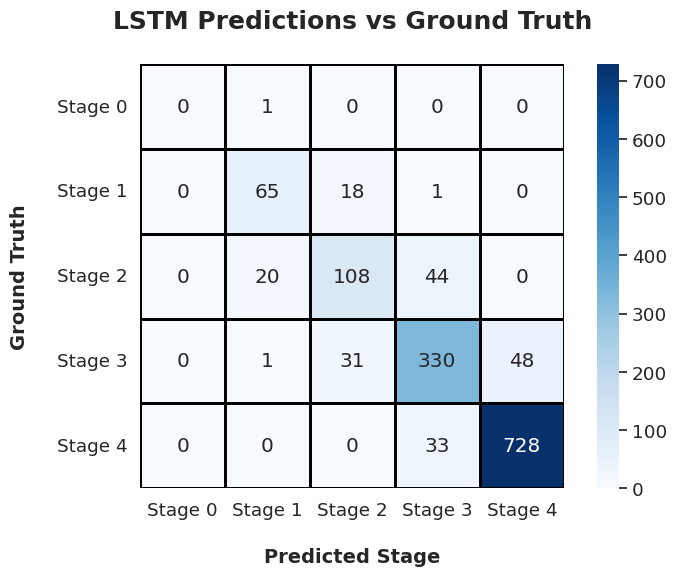

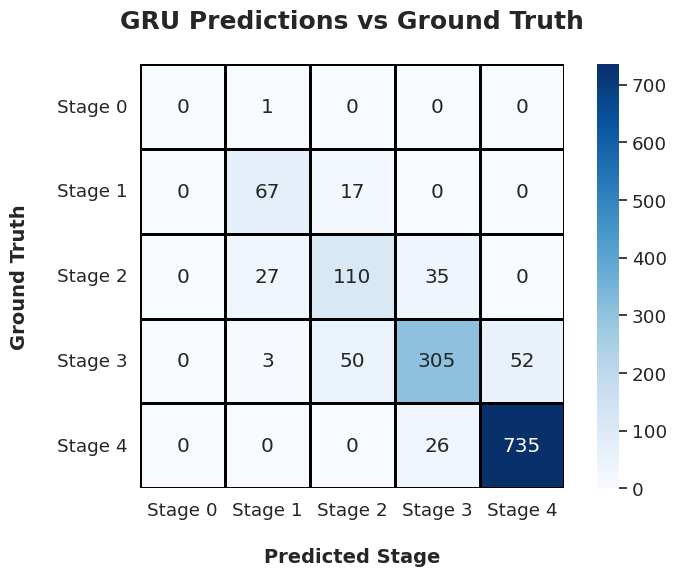

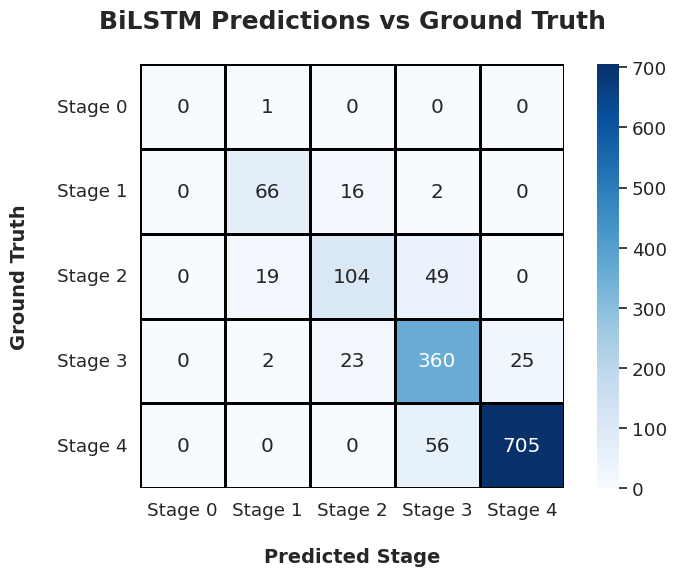

array([[  0,   1,   0,   0,   0],
       [  0,  66,  16,   2,   0],
       [  0,  19, 104,  49,   0],
       [  0,   2,  23, 360,  25],
       [  0,   0,   0,  56, 705]])

In [36]:
base_path = "/content/drive/MyDrive/pheno_crop"

# LSTM
plot_confusion_matrix(
    csv_path=f"{base_path}/predictions_lstm.csv",
    model_name="LSTM"
)

# GRU
plot_confusion_matrix(
    csv_path=f"{base_path}/predictions_gru.csv",
    model_name="GRU"
)

# BiLSTM
plot_confusion_matrix(
    csv_path=f"{base_path}/predictions_bilstm.csv",
    model_name="BiLSTM"
)

In [37]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE


def plot_tsne(model_class, model_path, model_name, dataset):
    # 🔹 Load model
    model = model_class()
    model.load_state_dict(torch.load(model_path, map_location='cpu'))
    model.eval()

    embeddings = []
    labels = []

    print(f"\n🚀 Extracting embeddings from {model_name}...")

    with torch.no_grad():
        for i in range(len(dataset)):
            sample = dataset[i]

            s1 = sample['s1_feats'].unsqueeze(0)
            s2 = sample['s2_feats'].unsqueeze(0)

            x = torch.cat([s1, s2], dim=2)

            # 🔥 Extract embeddings depending on model type
            if hasattr(model, 'lstm'):
                _, (h, _) = model.lstm(x)
                embedding = h[-1].squeeze().numpy()

            elif hasattr(model, 'gru'):
                _, h = model.gru(x)
                embedding = h[-1].squeeze().numpy()

            else:
                raise ValueError("Model type not supported for embedding extraction")

            embeddings.append(embedding)
            labels.append(sample['label'].item())

    embeddings_array = np.array(embeddings)

    print("Running t-SNE...")

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embeddings_2d = tsne.fit_transform(embeddings_array)

    # 🔹 Create DataFrame
    df_tsne = pd.DataFrame({
        'X': embeddings_2d[:, 0],
        'Y': embeddings_2d[:, 1],
        'Stage': labels
    })

    # 🔹 Plot
    plt.figure(figsize=(8, 6))
    sns.set_theme(style="whitegrid")

    sns.scatterplot(
        x='X',
        y='Y',
        hue='Stage',
        palette='viridis',
        data=df_tsne,
        alpha=0.8,
        s=60
    )

    plt.title(f"{model_name} Latent Space (t-SNE)", fontsize=16)
    plt.legend(title="Stage")
    plt.tight_layout()
    plt.show()

    return df_tsne


🚀 Extracting embeddings from LSTM...
Running t-SNE...


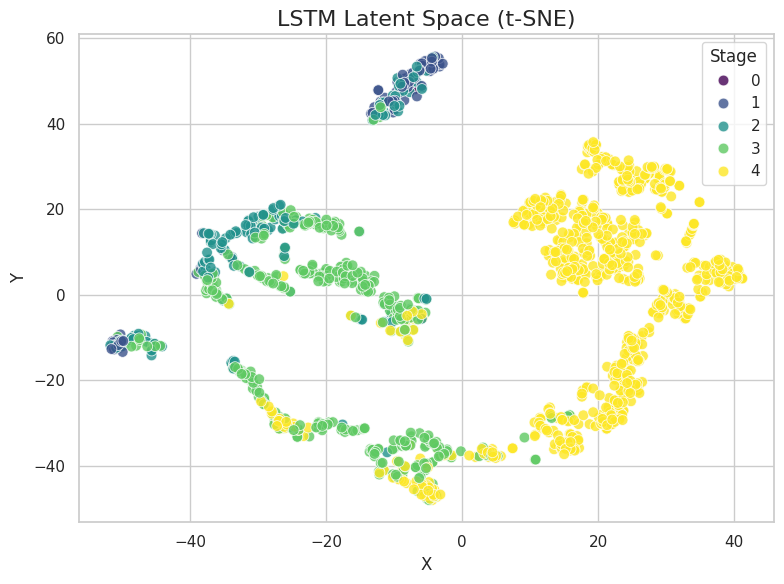


🚀 Extracting embeddings from GRU...
Running t-SNE...


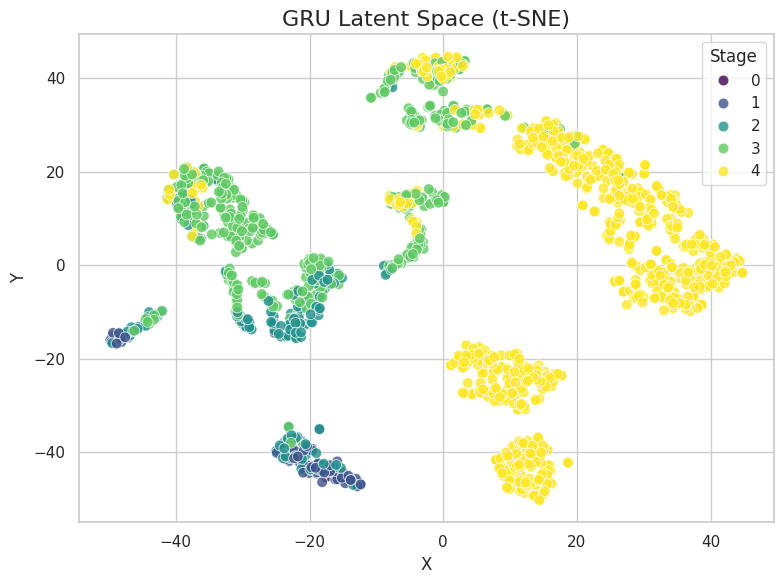


🚀 Extracting embeddings from BiLSTM...
Running t-SNE...


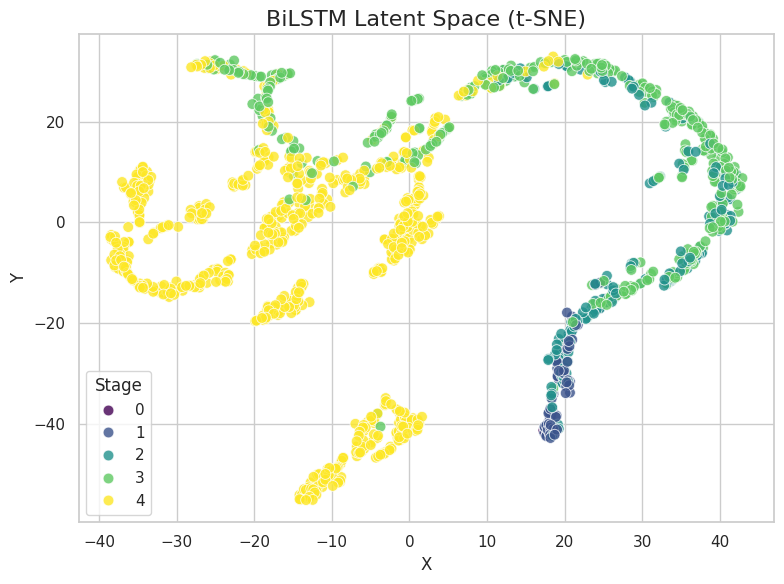

,X,Y,Stage
0,17.581301,-41.404442,1
1,19.516737,-31.149897,1
2,20.208557,-22.991652,1
3,24.331873,-16.316345,1
4,33.677094,-11.642603,2
...,...,...,...
1423,-13.326629,-54.968636,4
1424,-34.362679,9.994124,4
1425,-2.360242,-36.002174,4
1426,2.296737,12.031641,4


In [38]:
base_path = "/content/drive/MyDrive/pheno_crop"

# LSTM
plot_tsne(
    model_class=LSTMModel,
    model_path=f"{base_path}/best_model_lstm.pth",
    model_name="LSTM",
    dataset=full_dataset
)

# GRU
plot_tsne(
    model_class=GRUModel,
    model_path=f"{base_path}/best_model_gru.pth",
    model_name="GRU",
    dataset=full_dataset
)

# BiLSTM
plot_tsne(
    model_class=BiLSTMModel,
    model_path=f"{base_path}/best_model_bilstm.pth",
    model_name="BiLSTM",
    dataset=full_dataset
)